In [1]:
import heapq
import os.path

import matplotlib as mlp
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
import zipfile

from glob import glob
from functools import partial
from scipy.stats import rankdata
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skactiveml.classifier import SklearnClassifier, SkorchClassifier
from skactiveml.classifier.multiannotator import (
    CrowdLayerClassifierSkorch,
    AnnotMixClassifierSkorch,
)
from skactiveml.pool import (
    RandomSampling,
    SubSamplingWrapper,
    UncertaintySampling,
    TypiClust,
    Badge,
    DropQuery,
)
from skactiveml.utils import (
    call_func,
    MISSING_LABEL,
    is_unlabeled,
    is_labeled,
    majority_vote,
    rand_argmax,
    ExtLabelEncoder,
)
from skorch.callbacks import LRScheduler
from torch import nn
from torch.optim import RAdam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoImageProcessor, Dinov2Model


MISSING_LABEL = -1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
warnings.filterwarnings("ignore")

In [2]:
dataset_name = "letter"

if dataset_name == "Dopanim":
    zip_file = np.load(f"../{dataset_name}.zip")
    X_test = zip_file[f"{dataset_name}-test-X"]
    y_test = zip_file[f"{dataset_name}-test-y"]
    X_train = zip_file[f"{dataset_name}-train-X"]
    y_train = zip_file[f"{dataset_name}-train-y"]
    z_train = zip_file[f"{dataset_name}-train-z"]

elif dataset_name == "TREC-6":
    zip_path = f"../{dataset_name}.zip"

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(f"{dataset_name}-test-X.pt", "r") as f:
            X_test = (
                torch.load(f, map_location="cpu").numpy().astype(np.float32)
            )

        with z.open(f"{dataset_name}-test-y.pt", "r") as f:
            y_test = torch.load(f, map_location="cpu").numpy().astype(np.int64)

        with z.open(f"{dataset_name}-train-X.pt", "r") as f:
            X_train = (
                torch.load(f, map_location="cpu").numpy().astype(np.float32)
            )

        with z.open(f"{dataset_name}-train-y.pt", "r") as f:
            y_train = (
                torch.load(f, map_location="cpu").numpy().astype(np.int64)
            )

        # if z_train is also a torch tensor
        with z.open(f"{dataset_name}-train-z.pt", "r") as f:
            z_train = (
                torch.load(f, map_location="cpu").numpy().astype(np.int64)
            )
            z_train = z_train[:5452]

        train, valid = train_test_split(
            np.arange(5452), test_size=500, random_state=0, stratify=y_train
        )
        y_train = y_train[np.concat((train, valid))]
        X_train = X_train[np.concat((train, valid))]
elif dataset_name == "letter":
    zip_file = np.load(f"../{dataset_name}.zip")
    X_full = zip_file[f"{dataset_name}-X"]
    y_full = zip_file[f"{dataset_name}-y-true"]
    with zipfile.ZipFile(f"../{dataset_name}.zip", "r") as z:
        with z.open(f"{dataset_name}_sim_new.pt", "r") as f:
            z_full = torch.load(f, map_location="cpu").numpy().astype(np.int64)
    train, test = train_test_split(
            np.arange(len(y_full)), test_size=0.2, random_state=0, stratify=y_full
    )
    train, valid = train_test_split(
        train, test_size=500, random_state=0, stratify=y_full[train]
    )
    y_train = y_full[np.concat((train, valid))]
    X_train = X_full[np.concat((train, valid))]
    z_train = z_full[:len(np.concat((train, valid)))]
    y_test = y_full[test]
    X_test = X_full[test]
    sc = StandardScaler().fit(X_train)
    X_train = sc.transform(X_train)
    X_test = sc.transform(X_test)
classes = np.unique(y_train)

In [3]:
1-np.mean(y_train[:, None] == z_train)

np.float64(0.49697499999999994)

In [4]:
class ClassificationModule(nn.Module):

    def __init__(self, n_classes, input_dim):
        super(ClassificationModule, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.SiLU()
        self.drop1 = nn.Dropout(0.25)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.SiLU()
        self.drop2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(128, n_classes)

    def forward(self, x):
        x_embed = self.fc2(self.drop1(self.act1(self.bn1(self.fc1(x)))))
        logits = self.fc3(self.drop2(self.act2(self.bn2(x_embed))))
        return logits, x_embed


class MajorityVoteClassifier(SkorchClassifier):

    def fit(self, X, y, **fit_params):
        y = majority_vote(
            y,
            classes=self.classes,
            missing_label=self.missing_label,
            random_state=self.random_state,
        )
        return self._fit("fit", X, y, **fit_params)


classifier_dict = {}
classifier_dict["majority-vote"] = lambda random_state: MajorityVoteClassifier(
    module=ClassificationModule,
    criterion=nn.CrossEntropyLoss,
    classes=classes,
    missing_label=MISSING_LABEL,
    sample_dtype=np.float32,
    random_state=seed,
    neural_net_param_dict={
        # Module-related parameters.
        "module__n_classes": len(classes),
        "module__input_dim": X_train.shape[-1],
        "predict_nonlinearity": nn.Softmax(dim=-1),
        # Optimizer-related parameters.
        "max_epochs": 50,
        "optimizer": RAdam,
        "optimizer__weight_decay": 0.0,
        "optimizer__lr": 0.01,
        # General parameters.
        "train_split": False,
        "iterator_train__shuffle": True,
        "iterator_train__num_workers": 1,
        "iterator_train__batch_size": 32,
        "iterator_valid__batch_size": 64,
        "iterator_train__drop_last": True,
        "callbacks": [
            ("lr_scheduler", LRScheduler(policy=CosineAnnealingLR, T_max=50))
        ],
        "verbose": 0,
        "torch_load_kwargs": {"weights_only": True},
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },
)
def create_annot_mix(random_state, n_hidden_layers, s_dim=8, a_dim=8):
    return AnnotMixClassifierSkorch(
        clf_module=ClassificationModule,
        clf_sample_embed_dim=128,
        classes=classes,
        alpha=0.5,
        n_annotators=z_train.shape[1],
        sample_embed_dim=s_dim,
        annotator_embed_dim=a_dim,
        eta=0.9,
        n_hidden_layers=n_hidden_layers,
        hidden_dropout=0.0,
        missing_label=MISSING_LABEL,
        sample_dtype=np.float32,
        random_state=random_state,
        neural_net_param_dict={
            # Module-related parameters.
            "module__n_classes": len(classes),
            "module__input_dim": X_train.shape[-1],
            # Optimizer-related parameters.
            "max_epochs": 30,
            "optimizer": RAdam,
            "optimizer__weight_decay": 0.0,
            "optimizer__lr": 0.01,
            # General parameters.
            "train_split": False,
            "iterator_train__shuffle": True,
            "iterator_train__num_workers": 1,
            "iterator_train__batch_size": 32,
            "iterator_valid__batch_size": 64,
            "iterator_train__drop_last": True,
            "callbacks": [
                ("lr_scheduler", LRScheduler(policy=CosineAnnealingLR, T_max=30))
            ],
            "verbose": 0,
            "torch_load_kwargs": {"weights_only": True},
            "device": "cuda" if torch.cuda.is_available() else "cpu",
        },
    )
for n_hidden_layers in [0, 1, 2]:
    classifier_dict[f"annot-mix-{n_hidden_layers}"] = partial(create_annot_mix, n_hidden_layers=n_hidden_layers)


In [5]:
def _round_quotas(prev_loads: np.ndarray, k: int) -> np.ndarray:
    """
    Distribute k assignments to equalize TOTAL loads (prev + this round).
    Returns integer quotas q with sum(q) == k.
    """
    m = prev_loads.size
    q = np.zeros(m, dtype=int)
    # min-heap of (current_total_load, annotator_index)
    heap = [(int(prev_loads[a]), int(a)) for a in range(m)]
    heapq.heapify(heap)
    for _ in range(int(k)):
        load, a = heapq.heappop(heap)
        q[a] += 1
        heapq.heappush(heap, (load + 1, a))
    return q


def uniform_annotator_selection(is_available, n_labels_per_annotator, seed):
    """
    One annotator per sample, respecting availability, using many DISTINCT
    annotators first, while balancing against previous loads.

    Parameters
    ----------
    is_available : (n_samples, n_annotators) bool or {0,1}
        Availability matrix.
    n_labels_per_annotator : (n_annotators,) int
        Number of labels each annotator already handled before this round.
    seed : np.random.Generator, optional
        For tie-breaking.

    Returns
    -------
    assign : (n_samples,) int
        Chosen annotator for each sample, or -1 if none available.
    total_loads : (n_annotators,) int
        prev_loads + current round assignments.
    """
    A = np.asarray(is_available) > 0
    n, m = A.shape
    prev = np.asarray(n_labels_per_annotator, dtype=int)
    rng = np.random.RandomState(seed)

    # target number of assignments (one per sample if possible)
    k_max = int(np.count_nonzero(A.any(axis=1)))
    quotas = _round_quotas(prev, k_max)

    # Phase 1: maximum matching with capacity 1, only annotators with quota > 0
    neigh = [np.flatnonzero(A[i] & (quotas > 0)) for i in range(n)]
    # sort each neighbor list by (prev load, random tiebreak) WITHOUT using key=
    for i, cand in enumerate(neigh):
        if cand.size:
            rnd = rng.random(cand.size)
            order = np.lexsort(
                (rnd, prev[cand])
            )  # primary: prev[cand], secondary: rnd
            neigh[i] = cand[order]

    match_ann_to_samp = np.full(m, -1, dtype=int)
    assign = np.full(n, -1, dtype=int)

    order_samples = np.argsort([len(neigh[i]) for i in range(n)])

    def dfs(u: int, seen: np.ndarray) -> bool:
        for a in neigh[u]:
            if seen[a]:
                continue
            seen[a] = True
            v = match_ann_to_samp[a]
            if v == -1 or dfs(v, seen):
                match_ann_to_samp[a] = u
                assign[u] = a
                return True
        return False

    for u in order_samples:
        if len(neigh[u]) == 0:
            continue
        seen = np.zeros(m, dtype=bool)
        dfs(u, seen)

    # loads accrued this round so far; reduce quotas for matched annotators
    cur_loads = np.zeros(m, dtype=int)
    for a in np.flatnonzero(match_ann_to_samp != -1):
        quotas[a] -= 1
        cur_loads[a] += 1

    # Phase 2: balance remaining samples using quotas, then relax if needed
    remaining = np.flatnonzero(assign == -1)
    if remaining.size:
        remaining = remaining[
            np.argsort(A[remaining].sum(axis=1))
        ]  # fewest options first
        for i in remaining:
            cands = np.flatnonzero(A[i])
            if cands.size == 0:
                continue
            in_quota = cands[quotas[cands] > 0]
            pool = in_quota if in_quota.size else cands
            totals = prev[pool] + cur_loads[pool]
            best = pool[totals == totals.min()]
            a = rng.choice(best)
            assign[i] = a
            cur_loads[a] += 1
            if quotas[a] > 0:
                quotas[a] -= 1

    return assign


def greedy_annotator_performance_selection(
    is_available, clf, X, n_labels_per_annotator, explore, seed
):
    _, A_perf = clf.predict_proba(X, return_annotator_perf=True)
    print(A_perf.mean(axis=0))
    if explore:
        A_std = np.std(A_perf.mean(axis=0), axis=0)
        print(A_std)
        A_perf += A_std / np.sqrt(n_labels_per_annotator + 1)
        print(A_perf.mean(axis=0))
    A_perf = A_perf * is_available
    annot_query_index = rand_argmax(A_perf, axis=-1, random_state=seed)
    return annot_query_index

In [ ]:
sample_qs_dict = {
    "rand": lambda seed: RandomSampling(
        missing_label=MISSING_LABEL, random_state=seed
    ),
    # "typi-clust": lambda seed: TypiClust(
    # missing_label=MISSING_LABEL, random_state=seed
    # ),
    # "badge": lambda seed: Badge(
    #   missing_label=MISSING_LABEL, random_state=seed, clf_embedding_flag_name="return_embeddings"
    # ),
    # "us": lambda seed: UncertaintySampling(
    #   missing_label=MISSING_LABEL, random_state=seed,
    #   method="margin_sampling",
    # ),
}

annotator_qs_dict = {
    "uniform": uniform_annotator_selection,
    "best-greedy": partial(
        greedy_annotator_performance_selection, explore=False
    ),
    "best-explore": partial(
        greedy_annotator_performance_selection, explore=True
    ),
}

n_reps = 10
n_cycles = 30
query_batch_size = 256

results = {}

is_lbld_z_train = is_labeled(z_train, missing_label=MISSING_LABEL)
acc_per_annot = (
    (z_train == y_train[:, None])
    * is_labeled(z_train, missing_label=MISSING_LABEL)
).sum(axis=0) / is_labeled(z_train, missing_label=MISSING_LABEL).sum(axis=0)
labels_per_annot = is_labeled(z_train, missing_label=MISSING_LABEL).sum(axis=0)
print(f"# accuracy per annotator: {acc_per_annot}")

combs = []
for clf_name in classifier_dict:
    combs.append((clf_name, "rand", "uniform"))
    if clf_name.startswith("annot-mix"):
        combs.append((clf_name, "rand", "best-greedy"))


for clf_name, s_qs_name, a_qs_name in combs:
    print(clf_name)
    clf_acc = np.full((n_reps, n_cycles), np.nan)
    label_acc = np.full((n_reps, n_cycles), np.nan)
    for i_rep in range(n_reps):
        y = np.full_like(z_train, fill_value=MISSING_LABEL)

        for c in tqdm(
            range(n_cycles + 1),
            total=n_cycles,
            desc=f"Repetition {i_rep} of {clf_name}-{s_qs_name}-{a_qs_name}",
        ):
            # Create unique seed.
            state = np.random.SeedSequence([i_rep, c])
            seed = state.generate_state(1)[0]

            # Set global seed.
            np.random.seed(seed)
            torch.manual_seed(seed)
            torch.cuda.manual_seed(seed)

            # Classification.
            clf = classifier_dict[clf_name](random_state=seed)
            clf.fit(X_train, y)

            # Determine label states.
            is_unlbld_y = is_unlabeled(y, missing_label=MISSING_LABEL)
            is_lbld_y = is_labeled(y, missing_label=MISSING_LABEL)
            is_true_y = y == y_train[:, None]
            is_available = is_unlbld_y * is_lbld_z_train
            is_available = is_available.astype(float)
            n_labels = is_lbld_y.sum()
            n_correct_labels = (is_true_y * is_lbld_y).sum()
            n_labels_per_annot = is_lbld_y.sum(axis=0)
            n_labeled_samples = is_lbld_y.any(axis=-1).sum()

            if c > 0:
                label_acc[i_rep, c - 1] = n_correct_labels / n_labels
                clf_acc[i_rep, c - 1] = clf.score(X_test, y_test)
                print(f"n_labeled_samples: {n_labeled_samples}")
                print(f"n_labels_per_annot: {n_labels_per_annot}")
                print(f"n_labels: {n_labels_per_annot.sum()}")
                print(f"label-cc: {label_acc[i_rep, c-1]}")
                print(f"clf-acc: {clf_acc[i_rep, c-1]}")

            if c == n_cycles:
                break

            # Sample selection.
            # qs = SubSamplingWrapper(
            #    sample_qs_dict[s_qs_name](seed),
            #    exclude_non_subsample=True,
            #    random_state=seed,
            #    max_candidates=0.1,
            #    missing_label=MISSING_LABEL,
            # )
            qs = sample_qs_dict[s_qs_name](seed)
            candidates = np.flatnonzero(
                is_available.any(axis=1)  # & (y == -1).all(axis=1)
            )
            print(len(candidates))
            sample_query_idx = call_func(
                qs.query,
                X=X_train,
                y=majority_vote(y, missing_label=MISSING_LABEL),
                candidates=candidates,
                batch_size=query_batch_size,
                clf=clf,
                fit_clf=False,
            )

            # Annotator selection.
            if c > 0:
                annot_query_index = call_func(
                    annotator_qs_dict[a_qs_name],
                    is_available=is_available[sample_query_idx],
                    seed=seed,
                    clf=clf,
                    X=X_train[sample_query_idx],
                    y=y[sample_query_idx],
                    n_labels_per_annotator=n_labels_per_annot,
                )
            else:
                annot_query_index = uniform_annotator_selection(
                    is_available=is_available[sample_query_idx],
                    seed=seed,
                    n_labels_per_annotator=n_labels_per_annot,
                )

            # Labeling.
            query_idx = (sample_query_idx, annot_query_index)
            y[query_idx] = z_train[query_idx]

    results[f"{clf_name}_{s_qs_name}_{a_qs_name}_clf-acc"] = clf_acc
    results[f"{clf_name}_{s_qs_name}_{a_qs_name}_label-acc"] = label_acc

# accuracy per annotator: [0.7205    0.3670625 0.2063125 0.253     0.58775   0.633     0.4391875
 0.9260625 0.4251875 0.681375  0.7690625 0.5713125 0.0153125 0.2176875
 0.5201875 0.5119375 0.7906875 0.760875  0.2141875 0.4498125]
majority-vote


Repetition 0 of majority-vote-rand-uniform:   3%|▎         | 1/30 [00:00<00:05,  5.67it/s]

16000


Repetition 0 of majority-vote-rand-uniform:   7%|▋         | 2/30 [00:02<00:40,  1.43s/it]

n_labeled_samples: 256
n_labels_per_annot: [13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 12 12 12 12]
n_labels: 256
label-cc: 0.45703125
clf-acc: 0.42225
16000


...

n_labeled_samples: 1712
n_labels_per_annot: [90 90 90 90 90 90 90 90 90 90 90 90 89 89 89 89 89 89 89 89]
n_labels: 1792
label-cc: 0.4966517857142857
clf-acc: 0.6545
16000


Repetition 0 of majority-vote-rand-uniform:  30%|███       | 9/30 [00:33<01:44,  4.97s/it]

n_labeled_samples: 1946
n_labels_per_annot: [103 103 103 103 103 103 103 103 102 102 102 102 102 102 102 102 102 102
 102 102]
n_labels: 2048
label-cc: 0.498046875
clf-acc: 0.6695
16000


Repetition 0 of majority-vote-rand-uniform:  33%|███▎      | 10/30 [00:40<01:49,  5.46s/it]

n_labeled_samples: 2173
n_labels_per_annot: [116 116 116 116 115 115 115 115 115 115 115 115 115 115 115 115 115 115
 115 115]
n_labels: 2304
label-cc: 0.5013020833333334
clf-acc: 0.678
16000


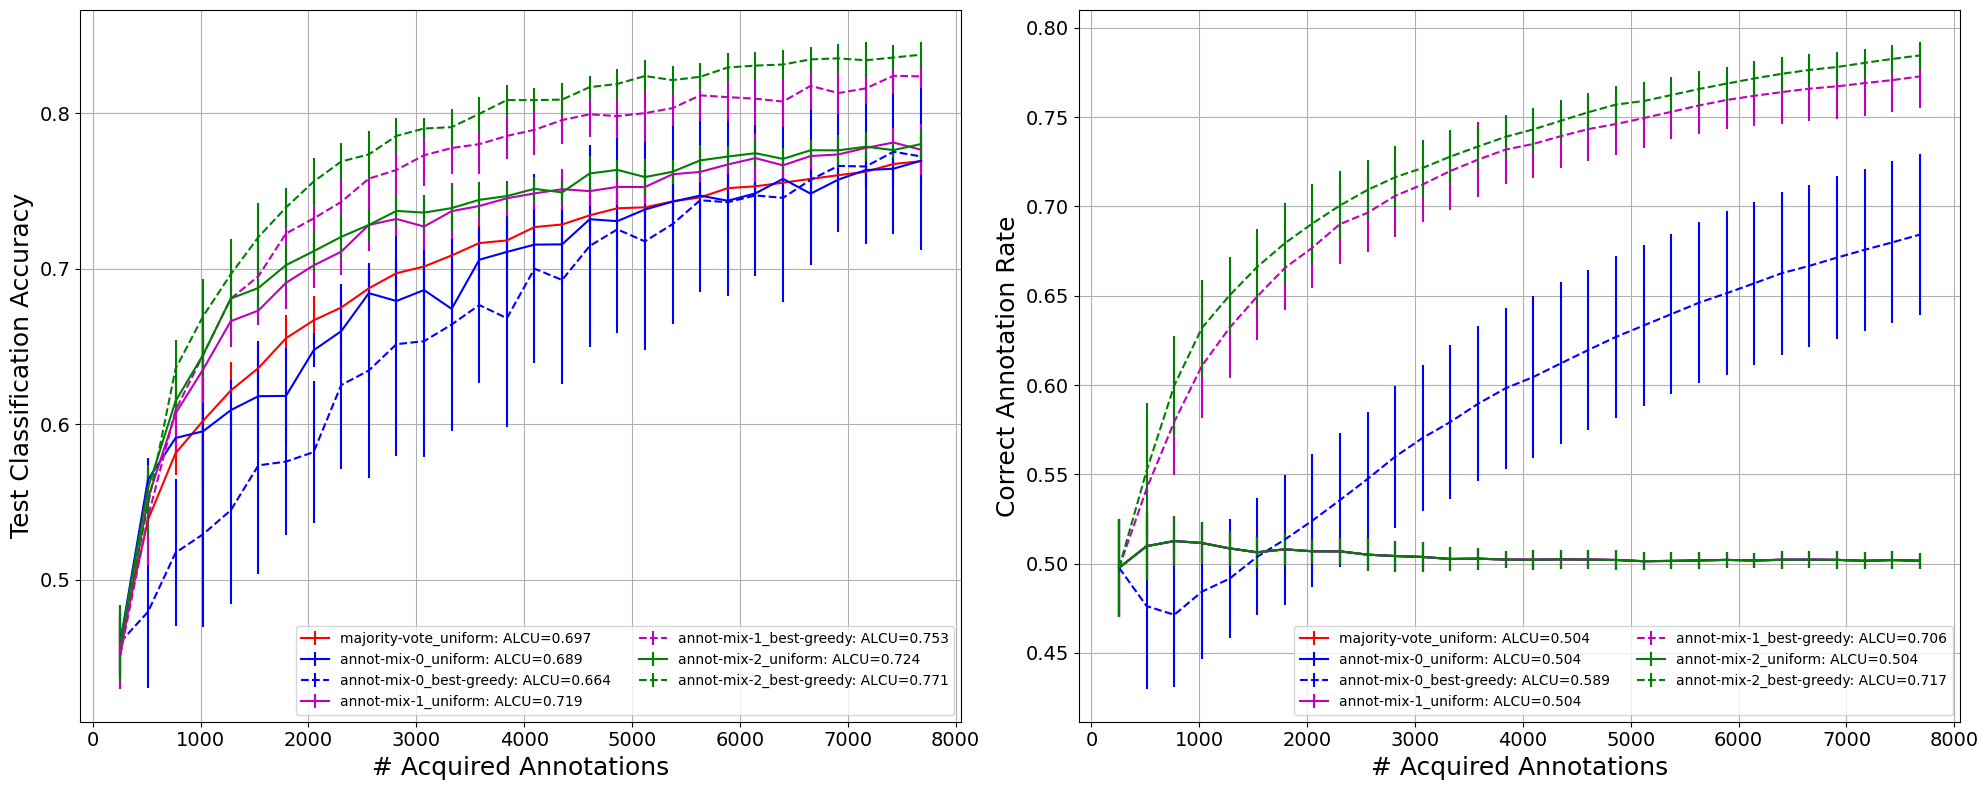

In [9]:
fix, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=False)
for clf_name, c in zip(classifier_dict, ["r", "b", "m", "g", "c"]):
        for annotator_qs_name, ls in zip(annotator_qs_dict, ["-", "--"]):
            for metric_name, ax in zip(["clf-acc", "label-acc"], axes):
                result = results.get(
                    f"{clf_name}_rand_{annotator_qs_name}_{metric_name}",
                    None,
                )
                if result is None:# or "-0" in clf_name or "-2" in clf_name:
                    continue
                reshaped_result = result.reshape((-1, n_cycles))
                errorbar_mean = np.mean(reshaped_result, axis=0)
                errorbar_std = np.std(reshaped_result, axis=0)
                ax.errorbar(
                    np.arange(1, n_cycles + 1) * query_batch_size,
                    errorbar_mean,
                    errorbar_std,
                    label=f"{clf_name}_{annotator_qs_name}: ALCU={np.mean(errorbar_mean):.3f}",
                    alpha=1,
                    color=c,
                    ls=ls,
                    markersize=0.1,
                )
                ax.grid()
                ax.legend(
                    fontsize=10,
                    loc="lower right",
                    ncol=2,
                    frameon=True,
                )
                ax.set_xlabel("# Acquired Annotations", fontsize=18)
                ax.set_ylabel(metric_name.replace("clf-acc", "Test Classification Accuracy").replace("label-acc", "Correct Annotation Rate"), fontsize=18)
                ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig(f"results-multi-annotators-{dataset_name}-{query_batch_size}.pdf")
plt.show()

In [14]:
import pandas as pd
import os

df = pd.concat(
    {k: pd.DataFrame(v) for k, v in results.items()}, names=["key", "row"]
)
df = df.reset_index(level=["key", "row"])
if not os.path.isfile(f"results-multi-annotators-{dataset_name}-{query_batch_size}.csv"):
    df.to_csv(
        f"results-multi-annotators-{dataset_name}-{query_batch_size}.csv",
        index=False,
    )